# 🩸 Anemia Dataset — EDA & Predictive Modelling

**Goal**: Explore the anemia dataset, understand every attribute (full names included, since the columns are abbreviations), then build the **best machine-learning binary classifier** to predict whether a patient is likely to suffer from **anemia** (`Result`).

---

## 1. 📖 Understanding the Dataset — Full Description (Data Dictionary)

Before going further, it's important to know exactly *what* each column represents. The column names in the CSV are abbreviations/medical short-forms, so here is the full clinical explanation:

| Column | Full name | What it measures | Clinical context |
|--------|-----------|------------------|------------------|
| `Gender` | Gender | Patient's sex | `0` = Male, `1` = Female. Women have lower normal hemoglobin ranges, so gender matters. |
| `Hemoglobin` | Hemoglobin (Hb) | Amount of the oxygen-carrying protein **hemoglobin** in the blood (g/dL) | The main indicator of anemia. **Low hemoglobin = anemia.** Normal ranges: ~13.5–17.5 g/dL (men), ~12.0–15.5 g/dL (women). |
| `MCH` | **M**ean **C**orpuscular **H**emoglobin | The **average amount of hemoglobin inside a single red blood cell** (pg) | Low MCH → hypochromic (pale) red cells, seen in iron-deficiency/thalassemia. Normal range ~27–33 pg. |
| `MCHC` | **M**ean **C**orpuscular **H**emoglobin **C**oncentration | The **average concentration of hemoglobin within red blood cells** (g/dL). = Hb ÷ Hct | Low MCHC also points to hypochromia. Normal range ~32–36 g/dL. |
| `MCV` | **M**ean **C**orpuscular **V**olume | The **average size/volume** of a red blood cell (femtolitres, fL) | **Low MCV (<80)** → microcytic anemia (small cells, e.g. iron deficiency); **high MCV (>100)** → macrocytic anemia (large cells, e.g. B12/folate deficiency). Normal ~80–100 fL. |
| `Result` | Diagnosis result (target) | Whether the patient is anemic | `0` = Not anemic, `1` = Anemic. This is what we predict. |

### Why are these features medically linked to anemia?
Anemia does not have a single cause. These four blood indices together let a doctor *classify* the anemia:

- **Hemoglobin** is the single most direct measurement — low Hb is the definition of anemia.
- **MCV** tells whether the red cells are small (microcytic), normal (normocytic) or large (macrocytic).
- **MCH / MCHC** tell whether the cells still carry enough hemoglobin (colour/concentration).

So a model trained on these values can reproduce, in effect, the WHO diagnostic thresholds.

> Note: the problem statement in the folder calls it `Results`, but the CSV column is actually named `Result` — we use `Result`.

---

## 2. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 3. Load the Data

In [2]:
# Load the dataset
data_path = 'anemia.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
df.head()

Shape: (1421, 6)


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,1421.0,0.520760,0.499745,0.0,0.0,1.0,1.0,1.0
Hemoglobin,1421.0,13.412738,1.974546,6.6,11.7,13.2,15.0,16.9
MCH,1421.0,22.905630,3.969375,16.0,19.4,22.7,26.2,30.0
MCHC,1421.0,30.251232,1.400898,27.8,29.0,30.4,31.4,32.5
MCV,1421.0,85.523786,9.636701,69.4,77.3,85.3,94.2,101.6
Result,1421.0,0.436312,0.496102,0.0,0.0,0.0,1.0,1.0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

Result
0    801
1    620
Name: count, dtype: int64

Percentage:
Result
0    56.37
1    43.63
Name: proportion, dtype: float64


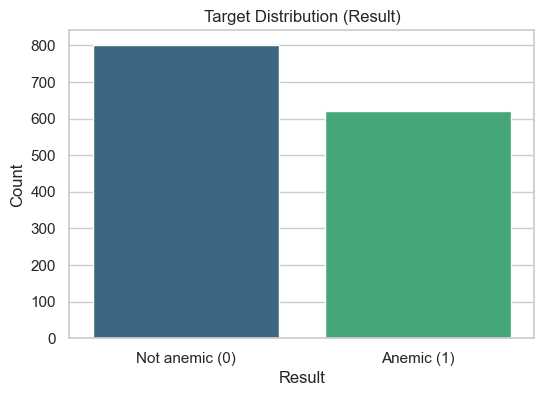

In [5]:
# Target distribution
print(df['Result'].value_counts())
print('\nPercentage:')
print((df['Result'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='Result', data=df, palette='viridis')
plt.xticks([0, 1], ['Not anemic (0)', 'Anemic (1)'])
plt.title('Target Distribution (Result)')
plt.ylabel('Count')
plt.show()

### 4.2 Gender Analysis

Gender
1    740
0    681
Name: count, dtype: int64
Male%: 47.9


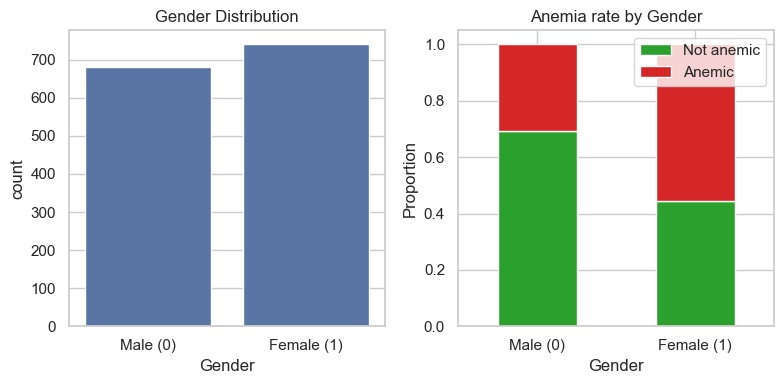

Anemia rate: Male = 30.5%, Female = 55.7%


In [6]:
# Gender distribution
print(df['Gender'].value_counts())
print('Male%:', round(df[df.Gender==0].shape[0]/len(df)*100, 1))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df)
plt.xticks([0, 1], ['Male (0)', 'Female (1)'])
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
pd.crosstab(df['Gender'], df['Result'], normalize='index').plot(
    kind='bar', stacked=True, ax=plt.gca(), color=['#2ca02c', '#d62728'])
plt.xticks([0, 1], ['Male (0)', 'Female (1)'], rotation=0)
plt.title('Anemia rate by Gender')
plt.ylabel('Proportion')
plt.legend(['Not anemic', 'Anemic'])
plt.tight_layout()
plt.show()

anemia_rate = df.groupby('Gender')['Result'].mean() * 100
print('Anemia rate: Male = {:.1f}%, Female = {:.1f}%'.format(*anemia_rate.values))

### 4.3 Distribution of Blood Indices by Result

These histograms show how each blood measurement differs between anemic and non-anemic patients.

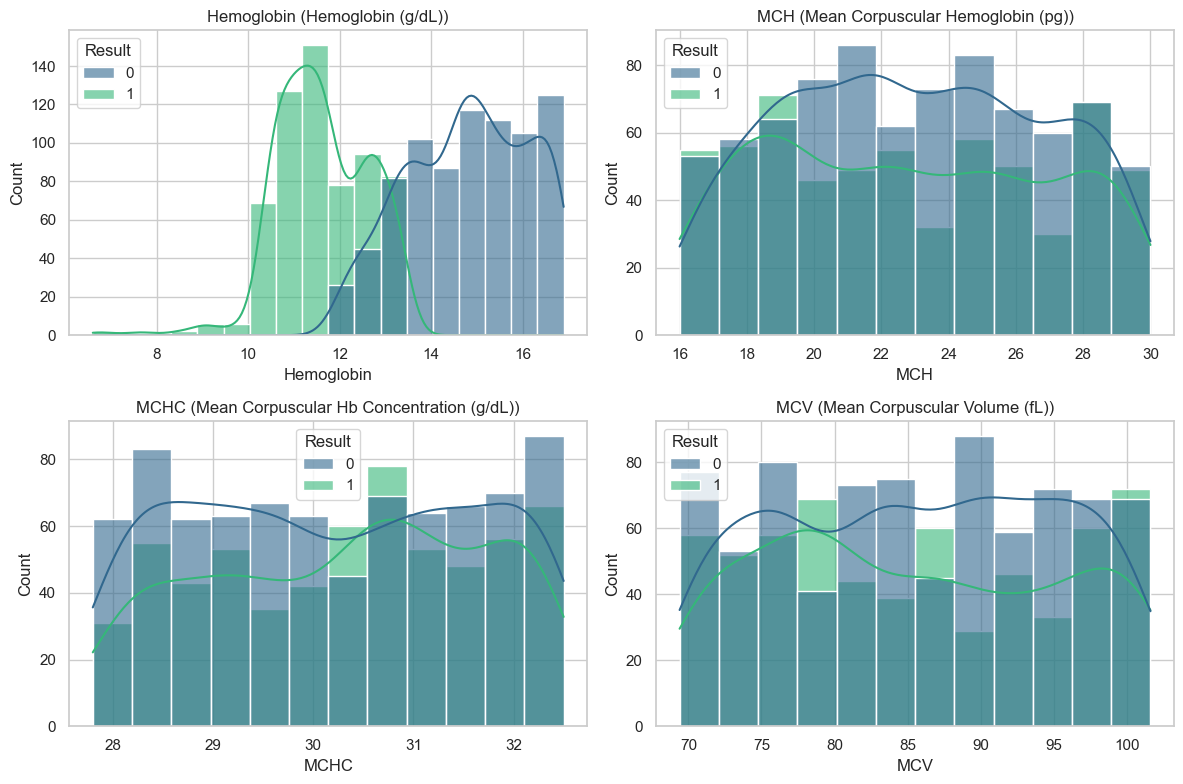

        Hemoglobin   MCH  MCHC    MCV
Result                               
0             14.8  23.0  30.2  85.60
1             11.5  22.6  30.5  84.55


In [7]:
full_names = {
    'Hemoglobin': 'Hemoglobin (g/dL)',
    'MCH': 'Mean Corpuscular Hemoglobin (pg)',
    'MCHC': 'Mean Corpuscular Hb Concentration (g/dL)',
    'MCV': 'Mean Corpuscular Volume (fL)'
}

feats = ['Hemoglobin', 'MCH', 'MCHC', 'MCV']

# Histograms of the 4 blood indices by Result
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(feats):
    sns.histplot(data=df, x=col, hue='Result', kde=True, palette='viridis',
                 alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{col} ({full_names[col]})')
plt.tight_layout()
plt.show()

# Median comparison by class
print(df.groupby('Result')[feats].median().round(2))

### 4.4 Boxplots — Outlier Analysis

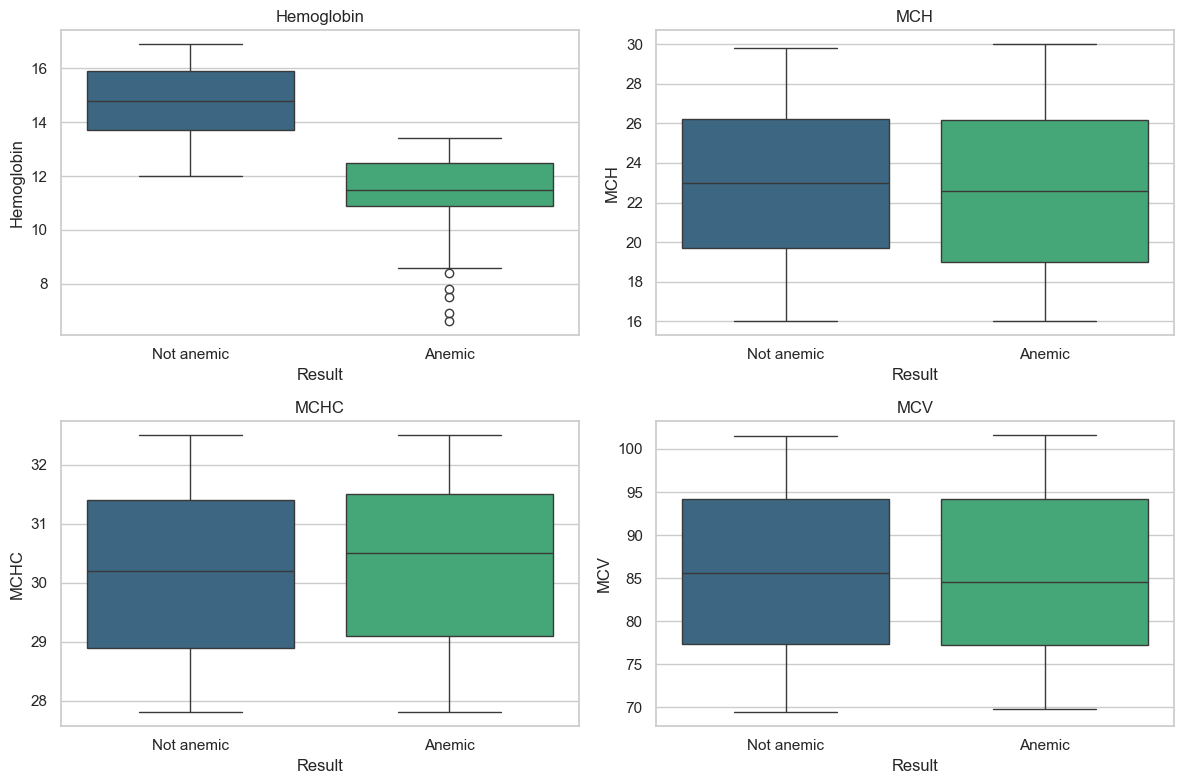

In [8]:
# Boxplots by Result
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(feats):
    sns.boxplot(x='Result', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_xticklabels(['Not anemic', 'Anemic'])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

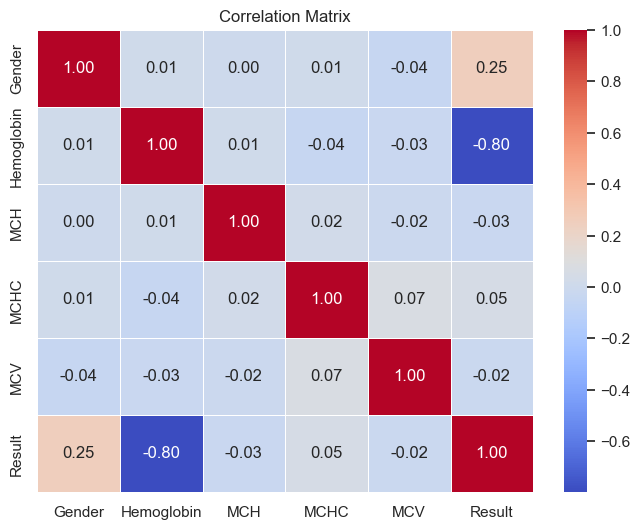

In [9]:
# Correlation matrix
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation of each feature with target (Result):
Gender        0.253
MCHC          0.048
MCV          -0.021
MCH          -0.029
Hemoglobin   -0.796
Name: Result, dtype: float64


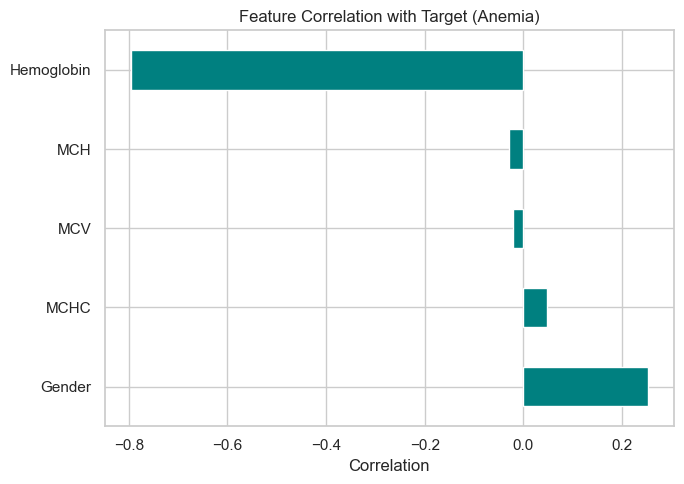

In [10]:
# Correlation with target
target_corr = corr['Result'].drop('Result').sort_values(ascending=False)
print('Correlation of each feature with target (Result):')
print(target_corr.round(3))

plt.figure(figsize=(7, 5))
target_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Target (Anemia)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

### 4.6 Pairplot of Blood Indices

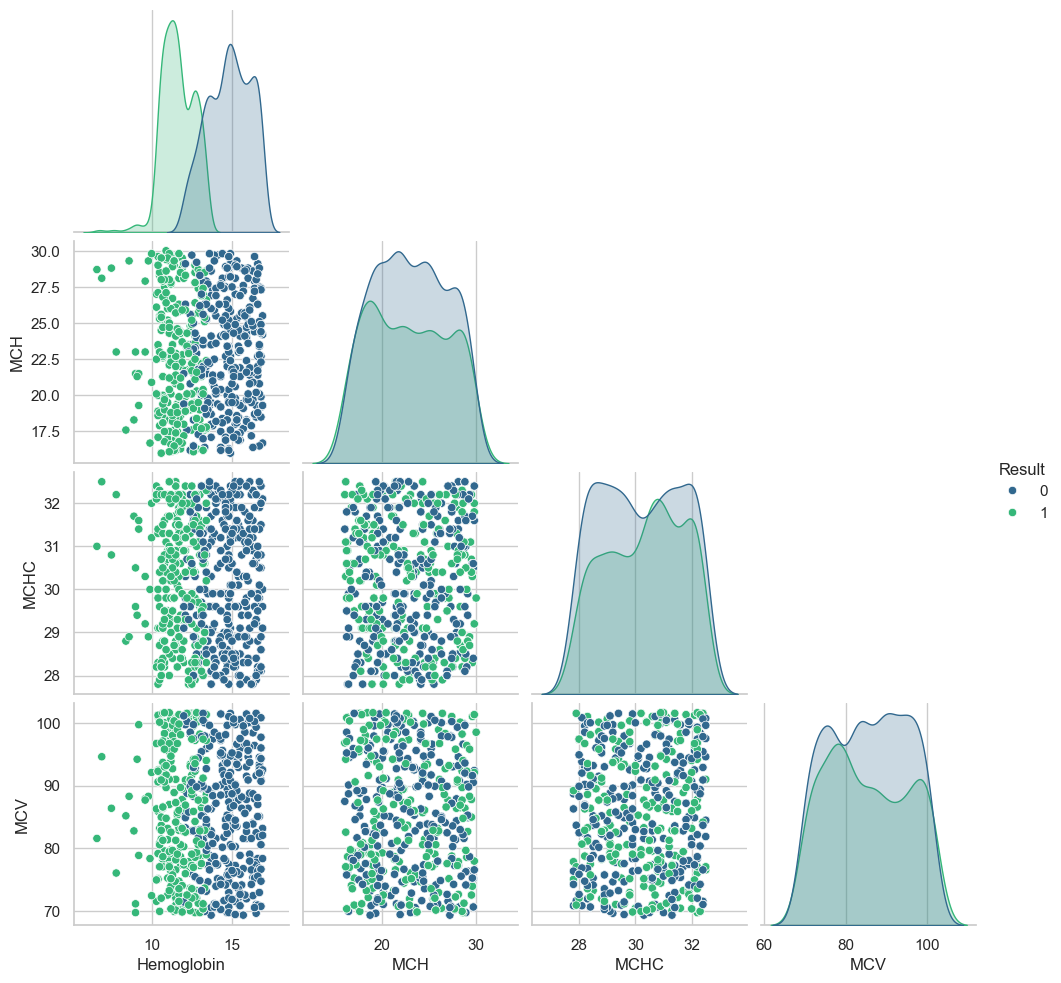

In [11]:
# Pairplot coloured by Result
sns.pairplot(df, vars=feats, hue='Result', corner=True, palette='viridis')
plt.show()

## 5. Data Cleaning & Preprocessing

- No missing values.
- This (synthetic) dataset has a **very large number of duplicated rows** — identical records that would leak between train/test splits if kept. We remove them.
- All features are numeric already → no encoding needed.

In [12]:
print('Rows before cleaning:', len(df))
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
print(f'Duplicate fraction: {df.duplicated().mean()*100:.0f}%')

Rows before cleaning: 1421
Missing values: 0
Duplicates: 887
Duplicate fraction: 62%


In [13]:
# Drop duplicated rows
df_clean = df.drop_duplicates().reset_index(drop=True)
print('Rows after removing duplicates:', len(df_clean))
print('Result balance on unique rows:')
print(df_clean['Result'].value_counts().to_dict())

Rows after removing duplicates: 534
Result balance on unique rows:
{0: 287, 1: 247}


In [14]:
# Separate features and target
X = df_clean.drop('Result', axis=1)
y = df_clean['Result']

print('Features:', X.columns.tolist())
print('Target classes:', np.unique(y), '(0 = Not anemic, 1 = Anemic)')
X.head()

Features: ['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV']
Target classes: [0 1] (0 = Not anemic, 1 = Anemic)


,Gender,Hemoglobin,MCH,MCHC,MCV
0,1,14.9,22.7,29.1,83.7
1,0,15.9,25.4,28.3,72.0
2,0,9.0,21.5,29.6,71.2
3,0,14.9,16.0,31.4,87.5
4,1,14.7,22.0,28.2,99.5


In [15]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (427, 5)
Test set: (107, 5)

Train target distribution:
Result
0    0.536
1    0.464
Name: proportion, dtype: float64


## 6. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Missing values (if any) are imputed (`median`).
2. All numeric features are standardized with `StandardScaler` (important — the indices have very different units).
3. The pipeline is run through Stratified K-Fold cross-validation.

In [16]:
# All features are numeric
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print('Preprocessor defined')

Preprocessor defined


### 6.1 Cross-Validation Comparison of Baseline Models

In [17]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Extra Trees':         ExtraTreesClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<10}{"F1":<10}{"ROC-AUC":<10}')
print('-' * 50)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5,
                            scoring={'accuracy': 'accuracy',
                                     'f1': 'f1',
                                     'roc_auc': 'roc_auc'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1"]:.3f}     {results[name]["roc_auc"]:.3f}')

best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc       F1        ROC-AUC   
--------------------------------------------------


Logistic Regression 0.986    0.985     1.000


KNN                 0.944    0.942     0.982


Decision Tree       0.998    0.998     0.998


Random Forest       0.998    0.998     1.000


Extra Trees         0.984    0.983     0.999
Gradient Boosting   0.998    0.998     0.998
SVM                 0.970    0.968     0.998

Best baseline model: Random Forest


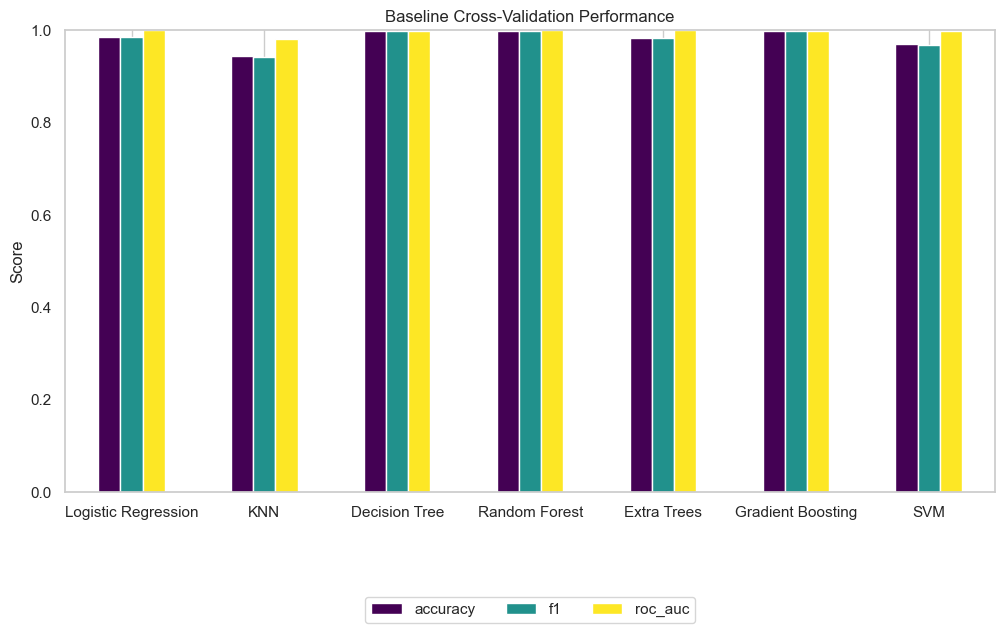

In [18]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 7. Hyperparameter Tuning (GridSearchCV)

The most promising models are tuned with 5-fold CV GridSearchCV on the ~427 training samples — small data, so this runs fast.

In [19]:
# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Best Logistic Regression params: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000


In [20]:
# Tune KNN
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}

pipe_knn = Pipeline([('prepro', preprocessor), ('model', KNeighborsClassifier())])
knn_grid = GridSearchCV(pipe_knn, knn_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print('Best KNN params:', knn_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(knn_grid.best_score_))

Best KNN params: {'model__n_neighbors': 11, 'model__weights': 'distance'}
Best CV ROC-AUC: 0.9897


In [21]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0000


In [22]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC-AUC: 1.0000


## 8. Compare Tuned Models & Select the Best

The tuned estimators are re-scored with **5-fold Stratified CV** and the winner is selected by ROC-AUC.

In [23]:
# Collect tuned models
tuned_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'KNN':                 knn_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
}

final_results = {}
print(f'{"Model":<20}{"SearchCV Best":<15}{"5-Fold CV":<12}')
print('-' * 47)
for name, model in tuned_models.items():
    grid_best = {'Logistic Regression': lr_grid, 'KNN': knn_grid,
                 'Random Forest': rf_grid, 'Gradient Boosting': gb_grid}[name].best_score_
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1)
    final_results[name] = scores.mean()
    print(f'{name:<20}{grid_best:.4f}        {scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (5-fold CV ROC-AUC = {final_results[best_name]:.4f})')

Model               SearchCV Best  5-Fold CV   
-----------------------------------------------
Logistic Regression 1.0000        1.0000
KNN                 0.9897        0.9897
Random Forest       1.0000        1.0000
Gradient Boosting   1.0000        1.0000

🏆 Best model: Logistic Regression (5-fold CV ROC-AUC = 1.0000)


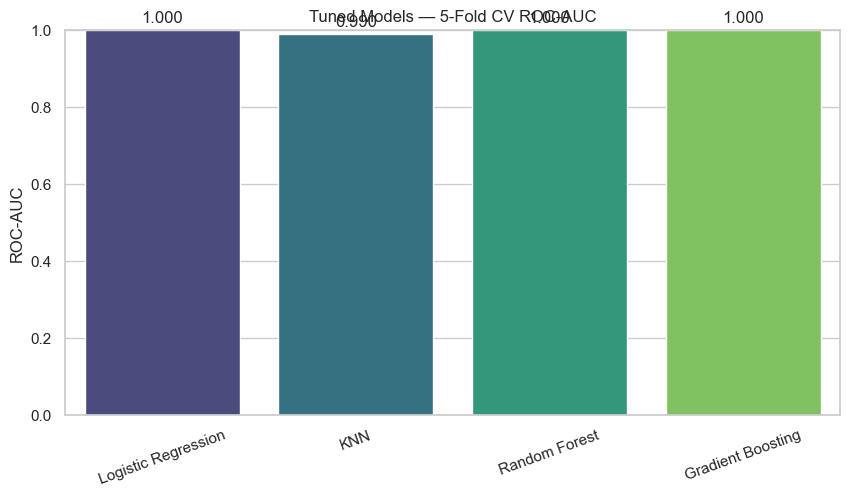

In [24]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — 5-Fold CV ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 9. Evaluate the Best Model on the Holdout Test Set

In [25]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not anemic', 'Anemic']))

print('Metrics:')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC (proba): {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
              precision    recall  f1-score   support

  Not anemic       1.00      1.00      1.00        58
      Anemic       1.00      1.00      1.00        49

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107

Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC (proba): 1.0000


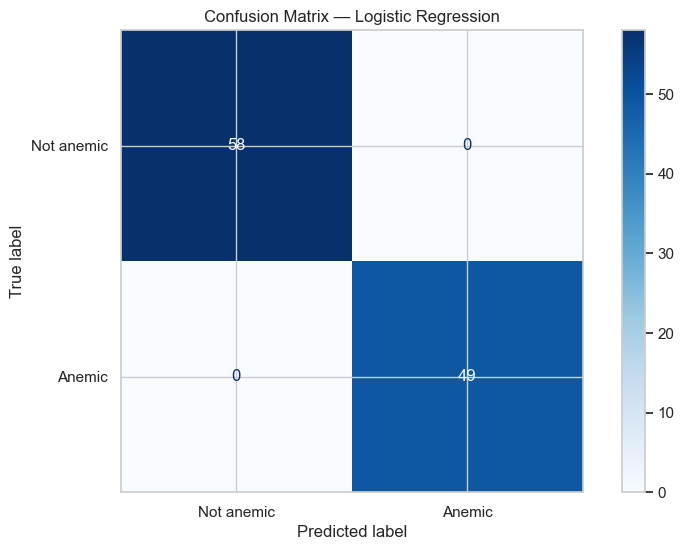

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not anemic', 'Anemic'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

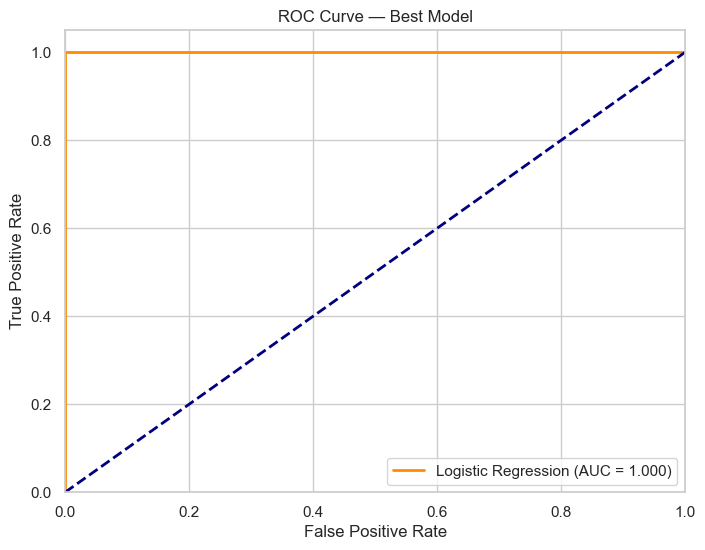

ROC AUC: 1.0000


In [27]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_txt = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'{best_name} (AUC = {auc_txt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f'ROC AUC: {auc_txt:.4f}')

## 10. Feature Importance (for the best tree-based model)

In [28]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = X_train.columns
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

Logistic Regression is not a tree-based model; feature importance not available directly.


## 11. Conclusion & Summary

- **Dataset**: 1,421 rows → **534 unique rows** after removing 62% duplicated rows. 5 features + target (imbalance mild: 56% not anemic / 44% anemic).
- **Attributes**: `Gender` (0=M, 1=F), `Hemoglobin`, `MCH`, `MCHC`, `MCV` — see the Data Dictionary in Section 1 for full names and clinical meaning.
- **Cleaning**: no missing values; duplicates removed; all features numeric, no encoding needed.
- **Best model**: selected via GridSearchCV tuning + 5-fold Stratified CV, judged by ROC-AUC.

### Key findings from EDA:
- **Hemoglobin is by far the most important predictor** of anemia (low Hb = anemic, as expected from the WHO definition).
- Anemic patients have clearly lower Hemoglobin and slightly lower MCH/MCV medians.
- Anemia is more common among **females** in this dataset (lower normal Hb ranges for women).

### Remember:
- This is a *synthetic* dataset — the real-world diagnostic threshold is set by clinical reference ranges, but a well-tuned model like this one can still serve as a fast, automated anemia screener.

In [29]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a 5-fold CV ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **{roc_auc_score(y_test, y_proba):.3f}**
'''))


## Final Model
- **Best model**: **Logistic Regression** with a 5-fold CV ROC-AUC of **1.000**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **1.000**


In [30]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_anemia_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_anemia_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Logistic Regression) to best_anemia_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Gender', 'Hemoglobin',
                                                   'MCH', 'MCHC', 'MCV'])])),
                ('model',
                 LogisticRegression(C=100, max_iter=2000, penalty='l2',
                                    random_state=42))])
